# Scenario Diversity Controlled Test — 軽量Screening

固定Actorのもとで、Cost Criticの学習データを次の2条件だけ変えて比較します。

- **B Repeat**: 10 geometry/N × 3 stochastic rollouts
- **C Diversity**: 30 geometry/N × 1 stochastic rollout

どちらも30 rollout/Nです。Bの10 geometryはCの30 geometryの部分集合です。Actor、Reference、Runtime HOCBF、Cost、network構造、1-step TDは固定します。Cost Critic ensembleだけを同一の新規初期値から学習します。

In [1]:
from pathlib import Path
from copy import deepcopy
import hashlib, json, math, platform, warnings
import numpy as np
import torch
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
from IPython.display import display

ROOT = Path.cwd().resolve()
if not (ROOT / 'uav_safe_marl').is_dir():
    ROOT = ROOT.parent
SOURCE_RUN = ROOT / 'runs' / 'mini_pilot_episodic_dcost6_mps'
SOURCE_CHECKPOINT = SOURCE_RUN / 'checkpoints' / 'final.pt'
OUTPUT_RUN = ROOT / 'runs' / 'scenario_diversity_screening'
AGENT_COUNTS = [2, 4, 8]
B_UNIQUE_PER_N, B_REPEATS = 10, 3
C_UNIQUE_PER_N, C_REPEATS = 30, 1
VALIDATION_UNIQUE_PER_N, VALIDATION_REPEATS = 10, 3
TIMEOUT_MULTIPLIER = 2.0
COST_CRITIC_SEED = 0
UPDATE_MILESTONES = [0, 1_000, 5_000, 10_000, 20_000]
TRANSITION_RATIO_TOLERANCE = (0.85, 1.15)
REGENERATE_BANKS = False
RECOLLECT_TRAINING_DATA = False
RECOLLECT_VALIDATION = False
RETRAIN_COST_CRITICS = False

for path in (SOURCE_CHECKPOINT, SOURCE_RUN / 'resolved_config.json'):
    if not path.exists(): raise FileNotFoundError(path)
OUTPUT_RUN.mkdir(parents=True, exist_ok=True)
SOURCE_SHA256 = hashlib.sha256(SOURCE_CHECKPOINT.read_bytes()).hexdigest()
print({'source': str(SOURCE_CHECKPOINT), 'sha256': SOURCE_SHA256[:16], 'output': str(OUTPUT_RUN)})

{'source': '/Users/iniad/Documents/#lab/Safe-RL_20260915/Codes/runs/mini_pilot_episodic_dcost6_mps/checkpoints/final.pt', 'sha256': '1a21a7a182e32ec3', 'output': '/Users/iniad/Documents/#lab/Safe-RL_20260915/Codes/runs/scenario_diversity_screening'}


In [2]:
print({'platform': platform.platform(), 'python': platform.python_version(), 'torch': torch.__version__, 'mps_available': torch.backends.mps.is_available()})
if not torch.backends.mps.is_available():
    raise RuntimeError('MPSが利用できません。VS Codeでプロジェクトの.venvカーネルを選択してください。')
probe = torch.ones((256, 256), device='mps')
print({'device': str(probe.device), 'probe': float((probe @ probe).sum().cpu())})
del probe

{'platform': 'macOS-15.6-arm64-arm-64bit-Mach-O', 'python': '3.13.3', 'torch': '2.14.0', 'mps_available': True}
{'device': 'mps:0', 'probe': 16777216.0}


In [3]:
from uav_safe_marl import build_env, load_config
from uav_safe_marl.evaluation import generate_random_traffic_bank, load_scenario_bank, save_scenario_bank
from uav_safe_marl.runners.trainer import SafeRLTrainer
from uav_safe_marl.runners.evaluator import evaluate

resolved = json.loads((SOURCE_RUN / 'resolved_config.json').read_text(encoding='utf-8'))
resolved['device'] = 'mps'
resolved['monitoring'].update({'enabled': True, 'progress_bar': True, 'tensorboard': False, 'auto_launch_tensorboard': False, 'open_browser': False})
resolved['training']['total_environment_steps_budget'] = None
config = load_config(ROOT / 'configs' / 'full.yaml', overrides=resolved)
settings = json.loads(json.dumps(resolved))
assert config.policy.backend.upper() == 'SAC' and config.safety.enabled
assert config.learning.d_cost == 6.0
print({'d_cost': config.learning.d_cost, 'gamma_cost': config.learning.gamma_cost, 'batch_size': config.learning.batch_size, 'runtime_hocbf': config.safety.enabled})

{'d_cost': 6.0, 'gamma_cost': 0.99, 'batch_size': 256, 'runtime_hocbf': True}


## 1. 完全分離scenario bank

C用master bankを先に生成し、Bはその先頭10 geometry/Nだけを使用します。Validationは別seedで生成し、trainingと完全分離します。

In [4]:
BANK_DIR = OUTPUT_RUN / 'banks'
BANK_DIR.mkdir(parents=True, exist_ok=True)
MASTER_PATH = BANK_DIR / 'master_c_30_per_n.json'
B_PATH = BANK_DIR / 'b_unique_10_per_n.json'
C_PATH = BANK_DIR / 'c_diversity_order.json'
VALIDATION_PATH = BANK_DIR / 'validation_10_per_n.json'

scenario_cfg = config.scenario
def generation_kwargs():
    return dict(
        base_size=scenario_cfg.longitudinal_length, transverse_size=scenario_cfg.transverse_size,
        spatial_scaling_mode='fixed', altitude_range=(scenario_cfg.altitude_min, scenario_cfg.altitude_max),
        minimum_initial_distance=scenario_cfg.minimum_initial_separation,
        d_safe=config.safety.d_safe, d_warn=config.safety.d_warn, d_eng=config.safety.d_eng,
        los_prediction_threshold=scenario_cfg.interaction_threshold, prediction_horizon=scenario_cfg.prediction_horizon,
        initial_speed_fraction_range=(scenario_cfg.initial_speed_fraction_min, scenario_cfg.initial_speed_fraction_max),
        acceleration_range=(2.0, 4.0), velocity_limit_range=(10.0, 14.0),
        require_predicted_conflict=True,
    )

def interleave(by_n, count):
    return [by_n[n][i] for i in range(count) for n in AGENT_COUNTS]

if REGENERATE_BANKS or not all(p.exists() for p in (MASTER_PATH, C_PATH, VALIDATION_PATH)):
    master_by_n = {n: generate_random_traffic_bank(n, C_UNIQUE_PER_N, seed=52_000 + n, **generation_kwargs()) for n in AGENT_COUNTS}
    c_scenarios = interleave(master_by_n, C_UNIQUE_PER_N)
    validation_by_n = {n: generate_random_traffic_bank(n, VALIDATION_UNIQUE_PER_N, seed=62_000 + n, **generation_kwargs()) for n in AGENT_COUNTS}
    validation_scenarios = interleave(validation_by_n, VALIDATION_UNIQUE_PER_N)
    save_scenario_bank(MASTER_PATH, c_scenarios)
    save_scenario_bank(C_PATH, c_scenarios)
    save_scenario_bank(VALIDATION_PATH, validation_scenarios)
else:
    c_scenarios = load_scenario_bank(C_PATH); validation_scenarios = load_scenario_bank(VALIDATION_PATH)

# A scenario bank is an exact-scenario set and therefore requires unique IDs.
# B's repeated stochastic rollouts are an execution schedule, not extra scenarios.
b_by_n = {n: [s for s in c_scenarios if int(s['actual_agent_count']) == n][:B_UNIQUE_PER_N] for n in AGENT_COUNTS}
b_base = interleave(b_by_n, B_UNIQUE_PER_N)
save_scenario_bank(B_PATH, b_base)
b_scenarios = [scenario for repeat in range(B_REPEATS) for scenario in b_base]

b_ids = {x['scenario_id'] for x in b_scenarios}
c_ids = {x['scenario_id'] for x in c_scenarios}
v_ids = {x['scenario_id'] for x in validation_scenarios}
assert b_ids < c_ids and not (c_ids & v_ids)
assert len(b_scenarios) == len(c_scenarios) == 90 and len(validation_scenarios) == 30
maximum_reference_time = max(max(item['reference_arrival_times']) for item in c_scenarios + validation_scenarios)
config.environment.max_steps = max(config.environment.max_steps, int(math.ceil(TIMEOUT_MULTIPLIER * maximum_reference_time / config.environment.dt_base)))
def scenario_bank_hash(items):
    return hashlib.sha256(json.dumps(items, sort_keys=True, separators=(',', ':'), default=str).encode()).hexdigest()
BANK_HASHES = {'B_repeat': scenario_bank_hash(b_scenarios), 'C_diversity': scenario_bank_hash(c_scenarios), 'validation': scenario_bank_hash(validation_scenarios)}
print({'B_rollouts': len(b_scenarios), 'B_unique': len(b_ids), 'C_rollouts': len(c_scenarios), 'C_unique': len(c_ids), 'validation_unique': len(v_ids), 'B_subset_C': b_ids < c_ids, 'max_steps': config.environment.max_steps})

{'B_rollouts': 90, 'B_unique': 30, 'C_rollouts': 90, 'C_unique': 90, 'validation_unique': 30, 'B_subset_C': True, 'max_steps': 1691}


## 2. 固定ActorでB/C Replayを収集

この段階ではgradient updateを一切行いません。各条件のReplayとepisode summaryを保存し、再実行時には再利用します。

In [5]:
def make_learned_actor_trainer(label):
    trainer = SafeRLTrainer(config, build_env(config), OUTPUT_RUN / label)
    trainer.load_checkpoint(SOURCE_CHECKPOINT, resume_training=False)
    return trainer

def module_snapshot(module):
    return {name: value.detach().cpu().clone() for name, value in module.state_dict().items()}

def frozen_snapshot(trainer):
    return {
        'actor': module_snapshot(trainer.backend.actor),
        'reward_critics': module_snapshot(trainer.backend.reward_critics),
        'reward_targets': module_snapshot(trainer.backend.reward_targets),
        'log_alpha': trainer.backend.log_alpha.detach().cpu().clone(),
        'lambda': float(trainer.backend.dual.value),
    }

def assert_frozen(trainer, before):
    for name, module in (('actor', trainer.backend.actor), ('reward_critics', trainer.backend.reward_critics), ('reward_targets', trainer.backend.reward_targets)):
        current = module.state_dict()
        if any(not torch.equal(value, current[key].detach().cpu()) for key, value in before[name].items()):
            raise RuntimeError(f'{name} changed')
    if not torch.equal(before['log_alpha'], trainer.backend.log_alpha.detach().cpu()): raise RuntimeError('alpha changed')
    if before['lambda'] != float(trainer.backend.dual.value): raise RuntimeError('lambda changed')

def collect_or_load(branch, scenarios):
    replay_path = OUTPUT_RUN / f'{branch}_fixed_actor_replay.pt'
    trainer = make_learned_actor_trainer(f'{branch}_collection')
    before = frozen_snapshot(trainer)
    if replay_path.exists() and not RECOLLECT_TRAINING_DATA:
        payload = torch.load(replay_path, map_location='cpu', weights_only=False)
        if payload.get('source_sha256') != SOURCE_SHA256 or payload.get('bank_sha256') != BANK_HASHES[branch]: raise RuntimeError(f'{branch} replay source/bank mismatch')
        trainer.buffer.load_state_dict(payload['replay_buffer']); history = payload['history']
        print(f'{branch}: 保存済みReplayを読み込みました。')
    else:
        history = trainer.train(episodes=len(scenarios), scenarios=scenarios, live_display=True, update_mode='collect_only')
        torch.save({'source_sha256': SOURCE_SHA256, 'bank_sha256': BANK_HASHES[branch], 'replay_buffer': trainer.buffer.state_dict(), 'history': history}, replay_path)
    assert_frozen(trainer, before)
    return trainer, history, replay_path

b_trainer, b_history, b_replay_path = collect_or_load('B_repeat', b_scenarios)
c_trainer, c_history, c_replay_path = collect_or_load('C_diversity', c_scenarios)

def dataset_summary(history, trainer):
    transitions = len(trainer.buffer)
    return {
        'episodes': len(history), 'transitions': transitions,
        'transitions_by_n': trainer.buffer.occupancy_by_agent_count(),
        'mean_episode_steps': float(np.mean([row['flight_time'] / config.environment.dt_base for row in history])),
        'mean_discounted_cost': float(np.mean([row['discounted_episode_cost'] for row in history])),
        'cost_positive_episode_fraction': float(np.mean([row['discounted_episode_cost'] > 0 for row in history])),
    }
dataset_stats = {'B_repeat': dataset_summary(b_history, b_trainer), 'C_diversity': dataset_summary(c_history, c_trainer)}
transition_ratio = dataset_stats['B_repeat']['transitions'] / dataset_stats['C_diversity']['transitions']
dataset_stats['transition_ratio_B_over_C'] = transition_ratio
if not TRANSITION_RATIO_TOLERANCE[0] <= transition_ratio <= TRANSITION_RATIO_TOLERANCE[1]:
    warnings.warn(f'B/C transition ratio={transition_ratio:.3f} is outside {TRANSITION_RATIO_TOLERANCE}; causal interpretation requires caution.')
(OUTPUT_RUN / 'dataset_summary.json').write_text(json.dumps(dataset_stats, ensure_ascii=False, indent=2), encoding='utf-8')
display(dataset_stats)

B_repeat: 保存済みReplayを読み込みました。
C_diversity: 保存済みReplayを読み込みました。


{'B_repeat': {'episodes': 90,
  'transitions': 40233,
  'transitions_by_n': {2: 13768, 4: 12662, 8: 13803},
  'mean_episode_steps': 447.03333333333336,
  'mean_discounted_cost': 9.916744802707266,
  'cost_positive_episode_fraction': 0.6777777777777778},
 'C_diversity': {'episodes': 90,
  'transitions': 39798,
  'transitions_by_n': {2: 12903, 4: 13253, 8: 13642},
  'mean_episode_steps': 442.2,
  'mean_discounted_cost': 10.352105261255563,
  'cost_positive_episode_fraction': 0.6888888888888889},
 'transition_ratio_B_over_C': 1.0109301974973617}

## 3. 共通Validation corpus

10 geometry/N × 3 stochastic repeatsを一度だけ生成します。各回の初回actionをQとrolloutで一致させ、全branch・milestoneで同じMC corpusを再利用します。

In [6]:
VALIDATION_CORPUS_PATH = OUTPUT_RUN / 'fixed_validation_corpus.pt'

def collect_validation_corpus():
    evaluator = make_learned_actor_trainer('validation_collection')
    before = frozen_snapshot(evaluator)
    corpus = []
    jobs = [(repeat, scenario) for repeat in range(VALIDATION_REPEATS) for scenario in validation_scenarios]
    try:
        for repeat, scenario in tqdm(jobs, desc='fixed held-out validation'):
            result = evaluate(evaluator, episodes=1, reset_options={'scenario': scenario}, policy_execution_mode='stochastic', pair_initial_action_with_cost=True, capture_critic_inputs=True)
            rollout = result['rollouts'][0]; metrics = result['episode_metrics'][0]
            if not metrics['paired_initial_action_matches_rollout'] or not metrics['paired_initial_nominal_matches_rollout']:
                raise RuntimeError(
                    'initial action pairing failed: '
                    f"execution_error={metrics['paired_initial_execution_action_max_abs_error']:.3e}, "
                    f"nominal_error={metrics['paired_initial_nominal_action_max_abs_error']:.3e}, "
                    f"scenario_id={metrics['scenario_id']}"
                )
            corpus.append({
                'scenario_id': metrics['scenario_id'], 'actual_agent_count': int(metrics['actual_agent_count']), 'repeat': repeat,
                'discounted_episode_cost': float(metrics['discounted_episode_cost']),
                'policy_observations': rollout['policy_observations'], 'policy_actions': rollout['policy_actions'],
                'nominal_actions': rollout['nominal_actions'], 'held_residual_actions': rollout['normalized_residual_actions'],
                'actor_phases': rollout['actor_phases'], 'costs': rollout['costs'],
            })
        assert_frozen(evaluator, before)
    finally:
        evaluator.env.close()
    torch.save({'source_sha256': SOURCE_SHA256, 'bank_sha256': BANK_HASHES['validation'], 'corpus': corpus}, VALIDATION_CORPUS_PATH)
    return corpus

if VALIDATION_CORPUS_PATH.exists() and not RECOLLECT_VALIDATION:
    payload = torch.load(VALIDATION_CORPUS_PATH, map_location='cpu', weights_only=False)
    if payload.get('source_sha256') != SOURCE_SHA256 or payload.get('bank_sha256') != BANK_HASHES['validation']: raise RuntimeError('validation corpus source/bank mismatch')
    validation_corpus = payload['corpus']
else:
    validation_corpus = collect_validation_corpus()
print({'validation_rollouts': len(validation_corpus), 'unique_scenarios': len({x['scenario_id'] for x in validation_corpus}), 'mc_mean': float(np.mean([x['discounted_episode_cost'] for x in validation_corpus]))})

fixed held-out validation:   0%|          | 0/90 [00:00<?, ?it/s]

{'validation_rollouts': 90, 'unique_scenarios': 30, 'mc_mean': 12.205756739469209}


## 4. Cost Criticの共通新規初期値

Ensemble member同士は独立に初期化します。そのensemble全体のstateをB/Cへ完全コピーし、Cost targetとoptimizerをリセットします。

In [7]:
COST_INIT_PATH = OUTPUT_RUN / 'common_cost_critic_initialization.pt'
if COST_INIT_PATH.exists() and not RETRAIN_COST_CRITICS:
    cost_initialization = torch.load(COST_INIT_PATH, map_location='cpu', weights_only=False)
    if cost_initialization.get('seed') != COST_CRITIC_SEED: raise RuntimeError('Cost initialization seed mismatch; set RETRAIN_COST_CRITICS=True')
else:
    init_dict = deepcopy(config.to_dict()); init_dict['seed'] = COST_CRITIC_SEED; init_dict['monitoring'].update({'enabled': False, 'progress_bar': False, 'tensorboard': False, 'auto_launch_tensorboard': False, 'open_browser': False})
    init_config = load_config(ROOT / 'configs' / 'full.yaml', overrides=init_dict)
    initializer = SafeRLTrainer(init_config, build_env(init_config), OUTPUT_RUN / 'cost_initializer')
    cost_initialization = {'seed': COST_CRITIC_SEED, 'cost_critics': module_snapshot(initializer.backend.cost_critics)}
    torch.save(cost_initialization, COST_INIT_PATH)
    initializer.env.close()

def apply_common_cost_initialization(trainer):
    trainer.backend.cost_critics.load_state_dict(cost_initialization['cost_critics'])
    trainer.backend.cost_targets.load_state_dict(cost_initialization['cost_critics'])
    trainer.backend.critic_optimizer = torch.optim.Adam(
        list(trainer.backend.reward_critics.parameters()) + list(trainer.backend.cost_critics.parameters()),
        lr=config.policy.learning_rate,
    )
    trainer.backend.cost_ucb_sample_count = 0; trainer.backend.cost_ucb_above_limit_count = 0

apply_common_cost_initialization(b_trainer); apply_common_cost_initialization(c_trainer)
b_init = module_snapshot(b_trainer.backend.cost_critics); c_init = c_trainer.backend.cost_critics.state_dict()
assert all(torch.equal(value, c_init[name].detach().cpu()) for name, value in b_init.items())
print({'cost_seed': COST_CRITIC_SEED, 'branch_initialization_identical': True, 'ensemble_members': config.learning.cost_ensemble_size})

{'cost_seed': 0, 'branch_initialization_identical': True, 'ensemble_members': 2}


## 5. Calibration集計関数

Start-stateはscenarioごとにstochastic repeatsを平均してから評価します。Temporal MAEはtrajectory内bin平均→scenario平均とし、長い危険episodeの支配を防ぎます。

In [8]:
def discounted_returns_to_go(costs, gamma):
    result = np.zeros_like(np.asarray(costs, dtype=float)); running = 0.0
    for index in range(len(result) - 1, -1, -1):
        running = float(costs[index]) + gamma * running; result[index] = running
    return result

def rankdata(values):
    values = np.asarray(values, dtype=float); ranks = np.empty(len(values), dtype=float)
    order = np.argsort(values, kind='mergesort'); sorted_values = values[order]; start = 0
    while start < len(values):
        end = start + 1
        while end < len(values) and sorted_values[end] == sorted_values[start]: end += 1
        ranks[order[start:end]] = (start + end - 1) / 2.0 + 1.0; start = end
    return ranks

def correlation(a, b):
    a=np.asarray(a,float); b=np.asarray(b,float)
    return None if len(a)<2 or np.std(a)==0 or np.std(b)==0 else float(np.corrcoef(a,b)[0,1])

def lead_bin(lead):
    if lead is None: return 'no_future_cost'
    if lead <= 10: return '0-10'
    if lead <= 50: return '11-50'
    if lead <= 150: return '51-150'
    return '151+'

def evaluate_validation(trainer, branch, milestone):
    rollout_rows=[]; trajectory_bins=[]
    for item in tqdm(validation_corpus, desc=f'{branch} validation @{milestone}', leave=False):
        obs=item['policy_observations']; stats=trainer.backend.start_cost_statistics_for_action(obs[0], item['policy_actions'][0])
        rollout_rows.append({'branch':branch,'milestone':milestone,'scenario_id':item['scenario_id'],'actual_agent_count':item['actual_agent_count'],'repeat':item['repeat'],'mc':item['discounted_episode_cost'],'q_mean':stats['mean'],'q_ucb':stats['ucb']})
        costs=np.asarray(item['costs'],float); returns=discounted_returns_to_go(costs,config.learning.gamma_cost); positive=np.flatnonzero(costs>1e-12)
        selected={0}
        for event in positive: selected.update(max(0,int(event)-lag) for lag in (0,10,50,150,300))
        errors={}
        for t in sorted(selected):
            future=positive[positive>=t]; lead=None if not len(future) else int(future[0]-t); name=lead_bin(lead)
            q=trainer.backend.cost_statistics_for_nominal_action(obs[t],item['nominal_actions'][t],held_residual_action=item['held_residual_actions'][t],actor_phase=int(item['actor_phases'][t]))
            errors.setdefault(name,[]).append(abs(q['ucb']-returns[t]))
        for name,values in errors.items(): trajectory_bins.append({'scenario_id':item['scenario_id'],'repeat':item['repeat'],'lead_bin':name,'trajectory_mae':float(np.mean(values)),'state_count':len(values)})
    scenario_rows=[]
    for sid in sorted({r['scenario_id'] for r in rollout_rows}):
        group=[r for r in rollout_rows if r['scenario_id']==sid]
        scenario_rows.append({'scenario_id':sid,'actual_agent_count':group[0]['actual_agent_count'],'mc':float(np.mean([r['mc'] for r in group])),'q_mean':float(np.mean([r['q_mean'] for r in group])),'q_ucb':float(np.mean([r['q_ucb'] for r in group]))})
    mc=np.asarray([r['mc'] for r in scenario_rows]); ucb=np.asarray([r['q_ucb'] for r in scenario_rows]); limit=config.learning.d_cost
    actual=mc>limit; predicted=ucb>limit; tp=int(np.sum(actual&predicted)); fn=int(np.sum(actual&~predicted)); tn=int(np.sum(~actual&~predicted)); fp=int(np.sum(~actual&predicted))
    temporal={}
    for name in ('0-10','11-50','51-150','151+','no_future_cost'):
        scenario_values=[]
        for sid in sorted({r['scenario_id'] for r in trajectory_bins if r['lead_bin']==name}):
            values=[r['trajectory_mae'] for r in trajectory_bins if r['lead_bin']==name and r['scenario_id']==sid]; scenario_values.append(float(np.mean(values)))
        if scenario_values:
            temporal[name]={'scenario_balanced_mae':float(np.mean(scenario_values)),'valid_scenarios':len(scenario_values),'valid_trajectories':sum(r['lead_bin']==name for r in trajectory_bins)}
    summary={'branch':branch,'milestone':milestone,'scenario_count':len(scenario_rows),'mc_mean':float(mc.mean()),'ucb_mean':float(ucb.mean()),'mae':float(np.mean(np.abs(ucb-mc))),'rmse':float(np.sqrt(np.mean((ucb-mc)**2))),'pearson':correlation(mc,ucb),'spearman':correlation(rankdata(mc),rankdata(ucb)),'false_negative_rate':None if tp+fn==0 else fn/(tp+fn),'false_positive_rate':None if tn+fp==0 else fp/(tn+fp),'confusion':{'tp':tp,'fn':fn,'tn':tn,'fp':fp},'empirical_ucb_coverage':float(np.mean(mc<=ucb)),'temporal':temporal}
    summary['by_n']={}
    for n in sorted({r['actual_agent_count'] for r in scenario_rows}):
        group=[r for r in scenario_rows if r['actual_agent_count']==n]; n_mc=np.asarray([r['mc'] for r in group]); n_ucb=np.asarray([r['q_ucb'] for r in group]); n_actual=n_mc>limit; n_pred=n_ucb>limit
        n_tp=int(np.sum(n_actual&n_pred)); n_fn=int(np.sum(n_actual&~n_pred)); n_tn=int(np.sum(~n_actual&~n_pred)); n_fp=int(np.sum(~n_actual&n_pred))
        summary['by_n'][str(n)]={'scenario_count':len(group),'mc_mean':float(n_mc.mean()),'ucb_mean':float(n_ucb.mean()),'mae':float(np.mean(np.abs(n_ucb-n_mc))),'pearson':correlation(n_mc,n_ucb),'spearman':correlation(rankdata(n_mc),rankdata(n_ucb)),'false_negative_rate':None if n_tp+n_fn==0 else n_fn/(n_tp+n_fn),'false_positive_rate':None if n_tn+n_fp==0 else n_fp/(n_tn+n_fp),'confusion':{'tp':n_tp,'fn':n_fn,'tn':n_tn,'fp':n_fp}}
    return summary, rollout_rows, scenario_rows, trajectory_bins

## 6. B/C Cost Critic単独学習

両branchは同じbatch size・gradient update数です。各milestoneで固定Validation corpusを評価し、checkpointを保存します。

In [9]:
def write_jsonl(path, rows):
    with Path(path).open('w',encoding='utf-8') as stream:
        for row in rows: stream.write(json.dumps(row,ensure_ascii=False)+'\n')

def run_branch(trainer, branch):
    branch_dir=OUTPUT_RUN/branch; branch_dir.mkdir(parents=True,exist_ok=True); before=frozen_snapshot(trainer)
    summaries=[]; rollout_rows=[]; scenario_rows=[]; temporal_rows=[]; update_rows=[]; current=0
    for milestone in UPDATE_MILESTONES:
        checkpoint=branch_dir/f'backend_{milestone:06d}.pt'
        if checkpoint.exists() and not RETRAIN_COST_CRITICS:
            trainer.backend.load_state_dict(torch.load(checkpoint,map_location=trainer.backend.device,weights_only=False)); current=milestone
        else:
            for update in tqdm(range(current,milestone),desc=f'{branch}: Cost Critic only'):
                metrics=trainer.backend.update_cost_critic_only(trainer.buffer.sample(config.learning.batch_size))
                if (update+1)%100==0 or update+1==milestone: update_rows.append({'branch':branch,'updates':update+1,**metrics})
            current=milestone; torch.save(trainer.backend.state_dict(),checkpoint)
        assert_frozen(trainer,before)
        summary,rr,sr,tr=evaluate_validation(trainer,branch,milestone); summaries.append(summary); rollout_rows.extend(rr); scenario_rows.extend(sr); temporal_rows.extend(tr)
        print({k:summary[k] for k in ('branch','milestone','mae','pearson','spearman','false_negative_rate','false_positive_rate')})
    (branch_dir/'summary.json').write_text(json.dumps(summaries,ensure_ascii=False,indent=2),encoding='utf-8')
    write_jsonl(branch_dir/'validation_rollouts.jsonl',rollout_rows); write_jsonl(branch_dir/'validation_scenarios.jsonl',scenario_rows); write_jsonl(branch_dir/'temporal_trajectory_bins.jsonl',temporal_rows); write_jsonl(branch_dir/'cost_updates.jsonl',update_rows)
    return summaries

b_results=run_branch(b_trainer,'B_repeat'); c_results=run_branch(c_trainer,'C_diversity')
b_trainer.env.close(); c_trainer.env.close()

B_repeat: Cost Critic only: 0it [00:00, ?it/s]

B_repeat validation @0:   0%|          | 0/90 [00:00<?, ?it/s]

{'branch': 'B_repeat', 'milestone': 0, 'mae': 12.052768010893127, 'pearson': 0.3162932137889532, 'spearman': 0.44020436728221596, 'false_negative_rate': 1.0, 'false_positive_rate': 0.0}


B_repeat: Cost Critic only:   0%|          | 0/1000 [00:00<?, ?it/s]

B_repeat validation @1000:   0%|          | 0/90 [00:00<?, ?it/s]

...

C_diversity validation @10000:   0%|          | 0/90 [00:00<?, ?it/s]

{'branch': 'C_diversity', 'milestone': 10000, 'mae': 11.220754168512151, 'pearson': 0.5401616903754622, 'spearman': 0.5842590689042503, 'false_negative_rate': 1.0, 'false_positive_rate': 0.0}


C_diversity: Cost Critic only:   0%|          | 0/10000 [00:00<?, ?it/s]

C_diversity validation @20000:   0%|          | 0/90 [00:00<?, ?it/s]

{'branch': 'C_diversity', 'milestone': 20000, 'mae': 10.193862664977805, 'pearson': 0.4908126830133839, 'spearman': 0.5362408350302388, 'false_negative_rate': 0.7142857142857143, 'false_positive_rate': 0.0}


## 7. 比較図・保存

主判断は20,000 update時点のheld-out MAE、Pearson/Spearman、false negative、false positiveです。Temporalはscenario-balanced MAEを使用します。

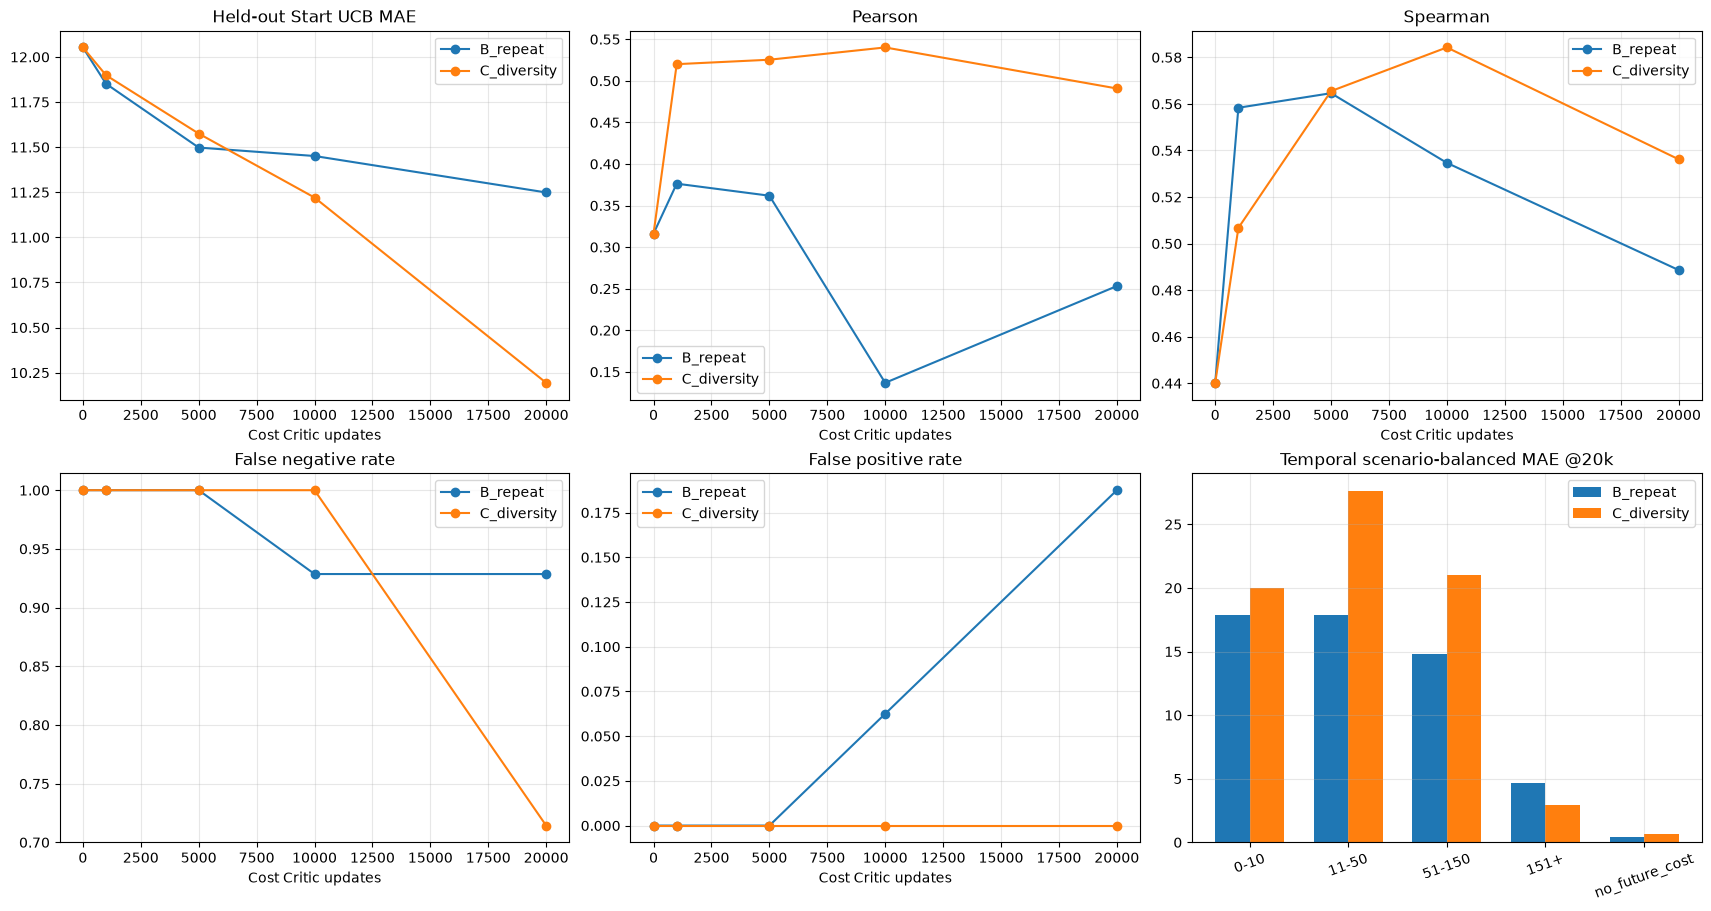

{'design': {'B': '10 geometry/N x 3 repeats',
  'C': '30 geometry/N x 1 repeat',
  'validation': '10 geometry/N x 3 repeats',
  'cost_critic_seed': 0},
 'dataset': {'B_repeat': {'episodes': 90,
   'transitions': 40233,
   'transitions_by_n': {2: 13768, 4: 12662, 8: 13803},
   'mean_episode_steps': 447.03333333333336,
   'mean_discounted_cost': 9.916744802707266,
   'cost_positive_episode_fraction': 0.6777777777777778},
  'C_diversity': {'episodes': 90,
   'transitions': 39798,
   'transitions_by_n': {2: 12903, 4: 13253, 8: 13642},
   'mean_episode_steps': 442.2,
   'mean_discounted_cost': 10.352105261255563,
   'cost_positive_episode_fraction': 0.6888888888888889},
  'transition_ratio_B_over_C': 1.0109301974973617},
 'B_final': {'branch': 'B_repeat',
  'milestone': 20000,
  'scenario_count': 30,
  'mc_mean': 12.20575673946921,
  'ucb_mean': 2.4560298506584433,
  'mae': 11.248917149036682,
  'rmse': 18.703931527956456,
  'pearson': 0.25315014529287083,
  'spearman': 0.48866928240156704,

Saved: /Users/iniad/Documents/#lab/Safe-RL_20260915/Codes/runs/scenario_diversity_screening/scenario_diversity_screening.png
All outputs: /Users/iniad/Documents/#lab/Safe-RL_20260915/Codes/runs/scenario_diversity_screening


In [10]:
results={'B_repeat':b_results,'C_diversity':c_results}
fig,axes=plt.subplots(2,3,figsize=(17,9),constrained_layout=True)
for branch,color in (('B_repeat','tab:blue'),('C_diversity','tab:orange')):
    rows=results[branch]; x=[r['milestone'] for r in rows]
    axes[0,0].plot(x,[r['mae'] for r in rows],marker='o',color=color,label=branch)
    axes[0,1].plot(x,[r['pearson'] for r in rows],marker='o',color=color,label=branch)
    axes[0,2].plot(x,[r['spearman'] for r in rows],marker='o',color=color,label=branch)
    axes[1,0].plot(x,[np.nan if r['false_negative_rate'] is None else r['false_negative_rate'] for r in rows],marker='o',color=color,label=branch)
    axes[1,1].plot(x,[np.nan if r['false_positive_rate'] is None else r['false_positive_rate'] for r in rows],marker='o',color=color,label=branch)
bins=['0-10','11-50','51-150','151+','no_future_cost']; final=rows[-1]
    # final temporal bars are drawn below
for offset,(branch,color) in enumerate((('B_repeat','tab:blue'),('C_diversity','tab:orange'))):
    final=results[branch][-1]; values=[final['temporal'].get(name,{}).get('scenario_balanced_mae',np.nan) for name in bins]
    axes[1,2].bar(np.arange(len(bins))+(offset-0.5)*0.35,values,width=0.35,color=color,label=branch)
axes[1,2].set_xticks(np.arange(len(bins)),bins,rotation=20)
for ax,title in zip(axes.flat,('Held-out Start UCB MAE','Pearson','Spearman','False negative rate','False positive rate','Temporal scenario-balanced MAE @20k')):
    ax.set_title(title); ax.grid(alpha=0.3); ax.legend()
for ax in axes[0,:]: ax.set_xlabel('Cost Critic updates')
axes[1,0].set_xlabel('Cost Critic updates'); axes[1,1].set_xlabel('Cost Critic updates')
figure_path=OUTPUT_RUN/'scenario_diversity_screening.png'; fig.savefig(figure_path,dpi=170); plt.show()
final_report={'design':{'B':'10 geometry/N x 3 repeats','C':'30 geometry/N x 1 repeat','validation':'10 geometry/N x 3 repeats','cost_critic_seed':COST_CRITIC_SEED},'dataset':dataset_stats,'B_final':b_results[-1],'C_final':c_results[-1]}
(OUTPUT_RUN/'final_report.json').write_text(json.dumps(final_report,ensure_ascii=False,indent=2),encoding='utf-8')
display(final_report)
print('Saved:',figure_path); print('All outputs:',OUTPUT_RUN)

## 判定

- **CのMAE・順位相関・false negativeが明確に良い**: scenario diversity仮説を支持。100 geometry/NとCost Critic seed 1/2の確認へ進む
- **B≈Cで両方改善**: geometry数よりstochastic data volumeの影響が大きい
- **CのStart汎化は改善するが51–150/151+だけ悪い**: long-horizon問題が独立して残るためn-step比較へ進む
- **Cでもheld-outが改善しない**: representation、Bellman target、Cost入力を監査する

このNotebookは診断専用です。Actor、CAL、`d_cost=6`、Cost定義は変更しません。